# E10 - EfficientNet-B3, augmentation only, 300px

| | |
|---|---|
| Architecture | `efficientnet_b3` |
| Imbalance strategy | `augmentation` |
| Input resolution | 300x300 |
| Group | EfficientNet-B3 ablation |
| Optimiser | Adam, lr 1e-3, betas (0.9, 0.999) |
| Batch size | 32 |
| Schedule | max 50 epochs, early stopping on val loss, patience 10 |
| Seed | 42 |

Same as E7 but at B3's native 300px. Everything else is identical, which
makes E7/E10 a clean paired test of whether the input size is doing the work.

Two practical differences: each epoch processes about 1.8x the pixels, so expect it to
run noticeably slower, and VRAM use goes up. Batch size stays at 32 because it is part
of the fixed protocol. If the GPU runs out of memory, do not quietly shrink the batch,
since that would break comparability with every other run. Use a larger GPU instead and
note it.

Training is checkpointed after every epoch. If the pod drops, re-run the training cell
and it picks up from the last completed epoch rather than starting over.

In [1]:
import json, sys, time
from pathlib import Path

# Works whether the kernel starts in notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "src" / "ham10000").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

# /workspace is a MooseFS network volume and per-file reads over FUSE were the
# bottleneck, not the GPU: 45 img/s there against 241 img/s from RAM. Notebook 01
# stages a copy into /dev/shm. Fall back to the on-disk copy if it is missing,
# since tmpfs does not survive a pod restart.
FAST = Path("/dev/shm/ham_data")
DATA = FAST if (FAST / "HAM10000_metadata.csv").exists() else ROOT / "data"
RUNS = ROOT / "runs"
print("repo:   ", ROOT)
print("data:   ", DATA, "(RAM)" if str(DATA).startswith("/dev/shm") else "(disk, slower)")

repo:    /workspace/ham10000-cnn-comparison
data:    /dev/shm/ham_data (RAM)


In [2]:
from ham10000.constants import EXPERIMENTS, experiment_label
from ham10000.train import TrainConfig, train_experiment

EXP = "E10"
print(experiment_label(EXP))
print(EXPERIMENTS[EXP])

E10 EfficientNet-B3 @300 / Augmentation only
{'architecture': 'efficientnet_b3', 'strategy': 'augmentation', 'image_size': 300}


## Preflight

Confirms the GPU, the data and the shared split before anything expensive starts.

In [3]:
import torch
from ham10000.split import load_or_create_split, split_hash

assert torch.cuda.is_available(), "No GPU. Stop here."
print("gpu :", torch.cuda.get_device_name(0))

assert (DATA / "HAM10000_metadata.csv").exists(), "Run notebook 01 first."
df, lesion_splits = load_or_create_split(DATA / "HAM10000_metadata.csv",
                                         RUNS / "splits" / "seed42_lesion_stratified.json")
print("split hash :", split_hash(lesion_splits))
print(df.split.value_counts().to_dict())

gpu : NVIDIA RTX A4500
split hash : f35ac1de18678182
{'train': 8012, 'test': 1024, 'val': 979}


## Train

Expect this to take a while. At 300px each epoch handles about 1.8x the pixels of the 224px runs, so budget accordingly.

The cell is safe to re-run: if `test_metrics.json` already exists it returns the cached
result instead of retraining. Pass `force_rerun=True` if you genuinely want it redone.

In [4]:
config = TrainConfig(
    experiment_id=EXP,
    data_root=str(DATA),
    output_dir=str(RUNS / EXP),
    seed=42,
    batch_size=32,
    lr=1e-3,
    max_epochs=50,
    patience=10,
    num_workers=16,
)

start = time.time()
result = train_experiment(config)
print(f"\nwall clock: {(time.time() - start) / 60:.1f} min")

Epoch 1/50 | train loss 0.6824 acc 0.7564 | val loss 0.5528 macro-F1 0.6106
Epoch 2/50 | train loss 0.5020 acc 0.8188 | val loss 0.5139 macro-F1 0.6953
Epoch 3/50 | train loss 0.4245 acc 0.8476 | val loss 0.5281 macro-F1 0.6990
Epoch 4/50 | train loss 0.3840 acc 0.8637 | val loss 0.5586 macro-F1 0.6827
Epoch 5/50 | train loss 0.3498 acc 0.8762 | val loss 0.5035 macro-F1 0.7028
Epoch 6/50 | train loss 0.3022 acc 0.8898 | val loss 0.5156 macro-F1 0.7086
Epoch 7/50 | train loss 0.2865 acc 0.8977 | val loss 0.4859 macro-F1 0.7460
Epoch 8/50 | train loss 0.2468 acc 0.9113 | val loss 0.5351 macro-F1 0.7468
Epoch 9/50 | train loss 0.2291 acc 0.9185 | val loss 0.4805 macro-F1 0.7592
Epoch 10/50 | train loss 0.2129 acc 0.9246 | val loss 0.4880 macro-F1 0.7473
Epoch 11/50 | train loss 0.2051 acc 0.9246 | val loss 0.4118 macro-F1 0.7908
Epoch 12/50 | train loss 0.1898 acc 0.9316 | val loss 0.4904 macro-F1 0.7104
Epoch 13/50 | train loss 0.1618 acc 0.9416 | val loss 0.4926 macro-F1 0.7731
Epoch 14

## Results

In [5]:
import pandas as pd
from ham10000.constants import CLASS_NAMES

m = result["test_metrics"]
report = m["classification_report"]

print(f"accuracy          {m['accuracy']:.4f}")
print(f"balanced accuracy {m['balanced_accuracy']:.4f}")
print(f"macro F1          {m['macro_f1']:.4f}")
print(f"macro AUC (OvR)   {m['macro_auc_ovr']:.4f}\n")

table = pd.DataFrame([{
    "class": c,
    "precision": report[str(i)]["precision"],
    "recall": report[str(i)]["recall"],
    "f1": report[str(i)]["f1-score"],
    "support": int(report[str(i)]["support"]),
} for i, c in enumerate(CLASS_NAMES)]).set_index("class").round(4)
print(table)

rq2 = (report[str(CLASS_NAMES.index("mel"))]["recall"]
       + report[str(CLASS_NAMES.index("bcc"))]["recall"]) / 2
print(f"\nRQ2 criterion, mean(recall MEL, recall BCC) = {rq2:.4f}")

accuracy          0.8350
balanced accuracy 0.6721
macro F1          0.7004
macro AUC (OvR)   0.9624

       precision  recall      f1  support
class                                    
akiec     0.5581  0.7273  0.6316       33
bcc       0.6939  0.6415  0.6667       53
bkl       0.6545  0.6857  0.6698      105
df        0.9000  0.6923  0.7826       13
mel       0.6275  0.5565  0.5899      115
nv        0.9175  0.9348  0.9261      690
vasc      1.0000  0.4667  0.6364       15

RQ2 criterion, mean(recall MEL, recall BCC) = 0.5990


### Training curve

Val loss is what early stopping watches. Val macro F1 is what actually matters, and the
two do not always move together.

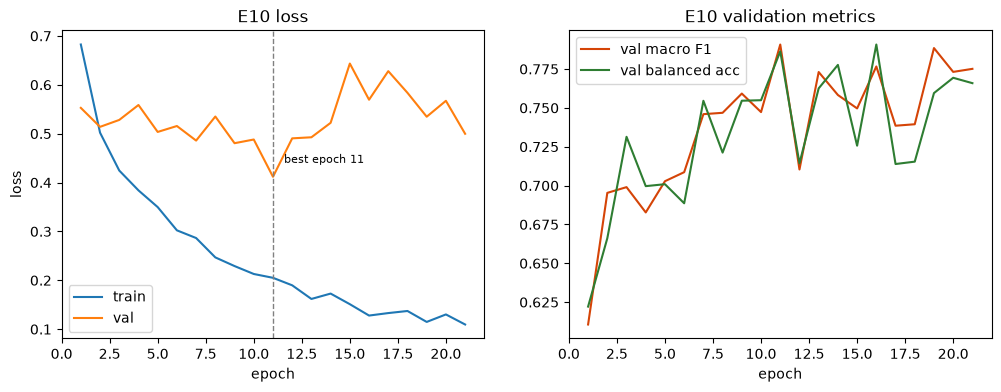

stopped after 21 epochs, best val loss 0.4118 at epoch 11


In [6]:
import matplotlib.pyplot as plt

h = pd.read_csv(RUNS / EXP / "history.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h.epoch, h.train_loss, label="train")
axes[0].plot(h.epoch, h.val_loss, label="val")
best = h.loc[h.val_loss.idxmin()]
axes[0].axvline(best.epoch, ls="--", c="grey", lw=1)
axes[0].annotate(f"best epoch {int(best.epoch)}", (best.epoch, best.val_loss),
                 textcoords="offset points", xytext=(8, 10), fontsize=8)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[0].set_title(f"{EXP} loss")

axes[1].plot(h.epoch, h.val_macro_f1, color="#D54407", label="val macro F1")
axes[1].plot(h.epoch, h.val_balanced_accuracy, color="#2E7D32", label="val balanced acc")
axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].set_title(f"{EXP} validation metrics")
plt.show()

print(f"stopped after {len(h)} epochs, best val loss {h.val_loss.min():.4f} at epoch {int(best.epoch)}")

### Confusion matrix

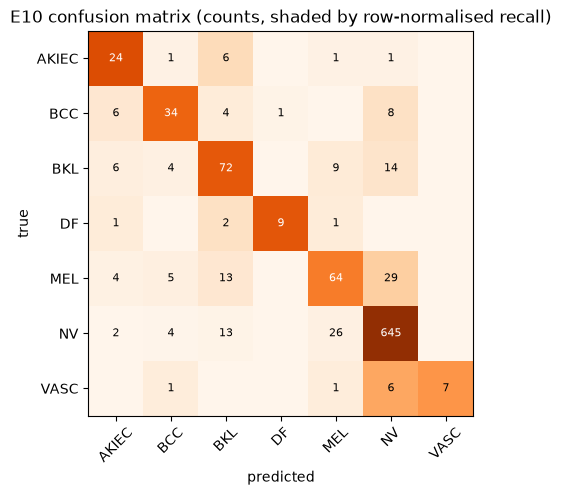

melanomas called NV: 29 of 115
This is the clinically costly error: a cancer sent home as a benign mole.


In [7]:
import numpy as np

cm = np.array(m["confusion_matrix"], dtype=float)
norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(norm, cmap="Oranges", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        if cm[i, j]:
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if norm[i, j] > 0.55 else "black")
ax.set_xticks(range(7), [c.upper() for c in CLASS_NAMES], rotation=45)
ax.set_yticks(range(7), [c.upper() for c in CLASS_NAMES])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"{EXP} confusion matrix (counts, shaded by row-normalised recall)")
ax.grid(False)
plt.show()

mel, nv = CLASS_NAMES.index("mel"), CLASS_NAMES.index("nv")
print(f"melanomas called NV: {int(cm[mel, nv])} of {int(cm[mel].sum())}")
print("This is the clinically costly error: a cancer sent home as a benign mole.")

### Files written

These five are what the analysis notebooks read. Nothing later re-derives them.

In [8]:
for f in sorted((RUNS / EXP).iterdir()):
    print(f"{f.name:<24} {f.stat().st_size/1e6:>8.2f} MB")

checkpoint_best.pt         129.34 MB
checkpoint_last.pt         129.34 MB
config.json                  0.00 MB
history.csv                  0.00 MB
test_metrics.json            0.00 MB
test_predictions.csv         0.02 MB
